## Module 4 — Classification

**Learning Objective**: Train and compare multiple classifiers.

📘 **Concepts: Different Ways to Draw a Decision Boundary**

Now that we've explored and preprocessed our data, it's time to build models that can make predictions. In this module, we'll focus on **classification**, which is a type of supervised learning where the goal is to predict a categorical label (e.g., 'setosa', 'versicolor', 'malignant', 'benign'). We'll introduce several common classification algorithms, each with a different approach to drawing the 'decision boundary' that separates classes.

### Logistic Regression

Despite its name, **Logistic Regression** is a classification algorithm. It works by fitting data to a logistic (or sigmoid) function, which outputs a probability. This probability is then mapped to a class. It's fundamentally a linear model, meaning it tries to find a straight line (or hyperplane in higher dimensions) that best separates the classes. While simple, it's a powerful baseline and highly interpretable.

### K-Nearest Neighbors (K-NN)

**K-NN** is a non-parametric, instance-based learning algorithm. It classifies a new data point based on the majority class among its 'K' nearest neighbors in the feature space. Imagine you have a new biological sample and you want to classify its type; K-NN would look at the K most similar samples already classified and assign the new sample the most common type among them. The 'decision boundary' is implicitly defined by the local density of points.

### Decision Tree

A **Decision Tree** classifies data by splitting it into smaller and smaller subsets based on feature values. It creates a tree-like structure where each internal node represents a 'test' on a feature (e.g., 'Is petal length > 2.45 cm?'), each branch represents the outcome of the test, and each leaf node assigns a class label. Decision trees are intuitive and easy to visualize, effectively partitioning the feature space with axis-parallel boundaries.

### Support Vector Machine (SVM)

**Support Vector Machines (SVMs)** are powerful algorithms for classification. The core idea is to find the hyperplane that maximally separates the different classes in the feature space. This separating hyperplane is often called the 'decision boundary'.

*   **Linear SVM**: When classes can be separated by a straight line (or hyperplane), a linear SVM finds the one that has the largest margin between the closest points of the different classes (these closest points are called 'support vectors').
*   **RBF Kernel SVM**: For more complex, non-linearly separable data, SVMs can use a 'kernel trick'. The **Radial Basis Function (RBF) kernel** (and others like polynomial or sigmoid) implicitly maps the data into a higher-dimensional space where a linear separation might be possible. This allows SVMs to create complex, non-linear decision boundaries in the original feature space. Think of it as inflating the data into a higher dimension to find a flat plane that separates it, then projecting that separation back down, creating a curved boundary.

### Random Forest

A single Decision Tree is easy to interpret but prone to overfitting -- it can carve out very specific boundaries that chase noise in the training data. A **Random Forest** fixes this by training many decision trees, each on a random subset of the data and a random subset of features, then having them vote on the final prediction (majority vote for classification). Averaging over many imperfect, decorrelated trees smooths out the noise any single tree would overfit to, which is why Random Forests are usually far more robust than a lone Decision Tree while keeping most of its interpretability -- each tree still splits on 'Is petal length > 2.45 cm?'-style questions, and the forest can report which features were used most often and most effectively across all its trees (**feature importance**).

🔬 **Why this matters in biology**

Classification algorithms are at the heart of many diagnostic and research applications in biology. For instance:

*   **Disease Diagnosis**: Classifying a patient's tumor as benign or malignant (as we saw with the Breast Cancer dataset) or predicting the presence/absence of a genetic disorder.
*   **Cell Type Identification**: Automatically classifying different cell types from microscopy images or single-cell RNA sequencing data.
*   **Protein Function Prediction**: Categorizing proteins into functional families based on their sequence or structural features.

Each classification model approaches the problem of drawing a 'decision boundary' differently. Understanding these differences helps biologists choose the most appropriate model for their specific data and scientific question. For example, a simple linear model might suffice for clearly separated data, while an RBF kernel SVM could handle more complex, overlapping biological distributions.

### Dataset: Iris and Breast Cancer

We will start by revisiting the **Iris dataset** for a multi-class classification problem, which is simple enough to visualize decision boundaries. Then, we will switch to the **Breast Cancer dataset** for a more realistic binary classification scenario with higher stakes, which also allows us to build upon the preprocessing we did in Module 2.


--- Iris Dataset Classification ---

Iris Classification Results:
Logistic Regression: Accuracy = 0.9333


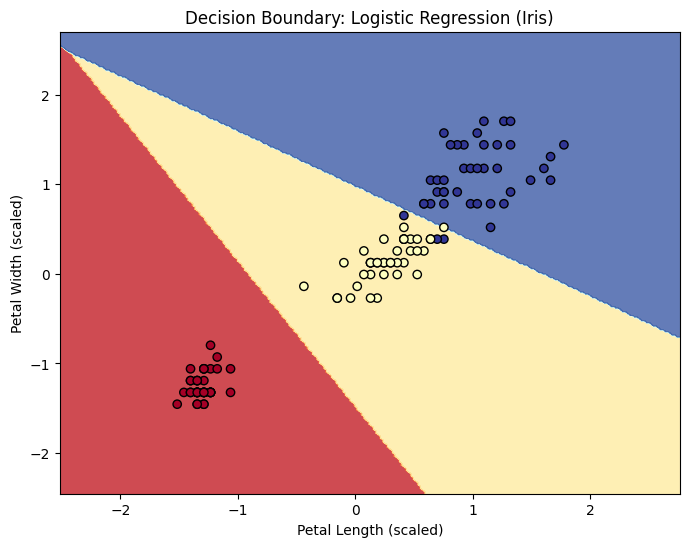

K-Nearest Neighbors: Accuracy = 0.9667


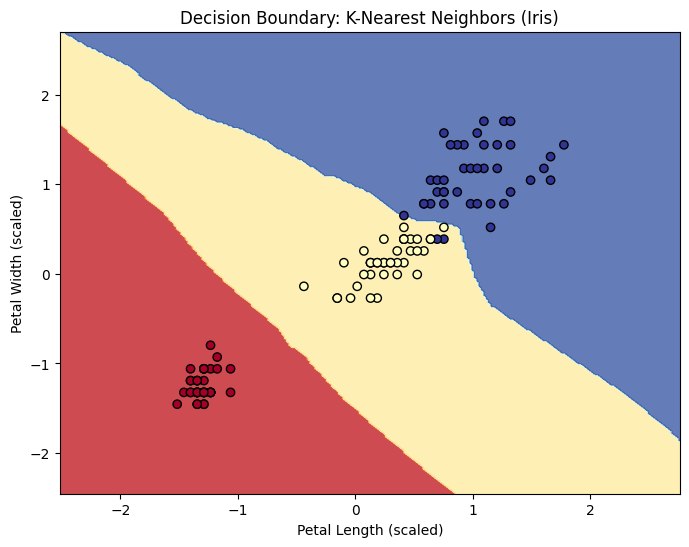

Decision Tree: Accuracy = 0.9333


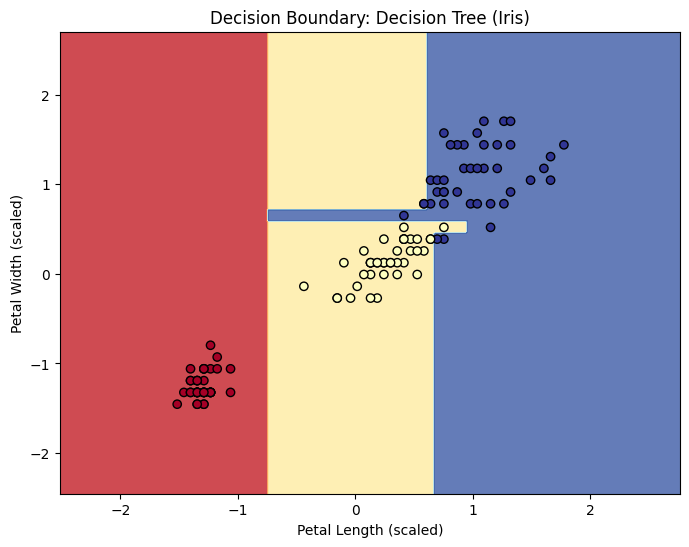

SVM (Linear): Accuracy = 0.9333


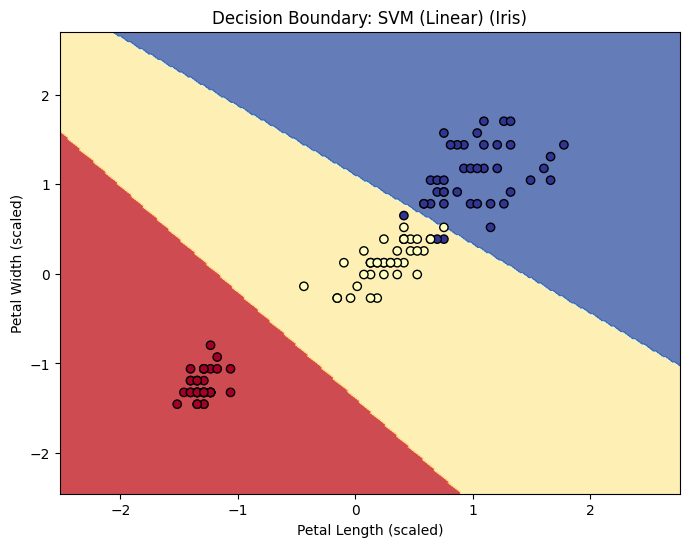

SVM (RBF): Accuracy = 0.9333


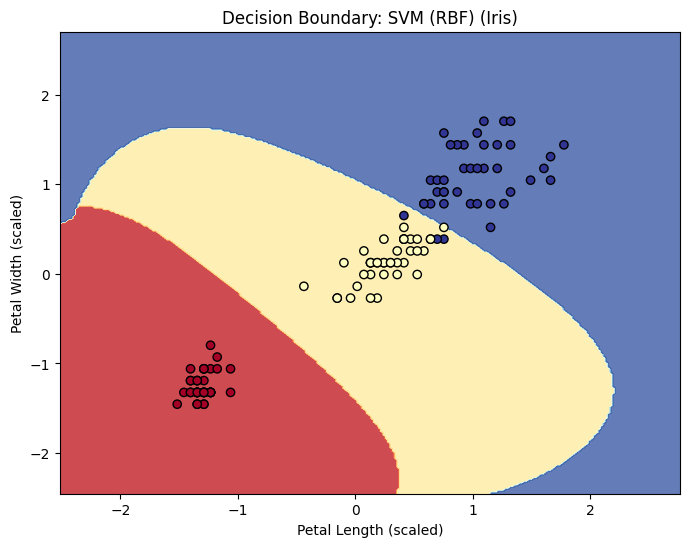


--- Breast Cancer Dataset Classification ---

Breast Cancer Classification Results:
Logistic Regression: Accuracy = 0.9825
K-Nearest Neighbors: Accuracy = 0.9561
Decision Tree: Accuracy = 0.9123
SVM (Linear): Accuracy = 0.9737
SVM (RBF): Accuracy = 0.9825

Comparison of Model Accuracies:
                     Iris Dataset Accuracy  Breast Cancer Dataset Accuracy
Logistic Regression               0.933333                        0.982456
K-Nearest Neighbors               0.966667                        0.956140
Decision Tree                     0.933333                        0.912281
SVM (Linear)                      0.933333                        0.973684
SVM (RBF)                         0.933333                        0.982456


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# --- Iris Dataset --- #
print("\n--- Iris Dataset Classification ---")
iris = load_iris()
X_iris, y_iris = iris.data[:, [2, 3]], iris.target # Using only Petal Length and Petal Width for visualization

# Split data (80/20 train/test split)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# Scale features
scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

# Models to compare
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42, probability=True),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Function to plot decision boundaries
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    plt.figure(figsize=(8, 6))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.xlabel('Petal Length (scaled)')
    plt.ylabel('Petal Width (scaled)')
    plt.title(title)
    plt.show()

iris_accuracies = {}
print("\nIris Classification Results:")
for name, clf in classifiers.items():
    clf.fit(X_iris_train_scaled, y_iris_train)
    y_pred = clf.predict(X_iris_test_scaled)
    accuracy = accuracy_score(y_iris_test, y_pred)
    iris_accuracies[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")
    plot_decision_boundary(X_iris_train_scaled, y_iris_train, clf, f'Decision Boundary: {name} (Iris)')

# --- Breast Cancer Dataset --- #
print("\n--- Breast Cancer Dataset Classification ---")
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# Use the same split and scaling logic as Module 2 for consistency
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

scaler_bc = StandardScaler()
X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled = scaler_bc.transform(X_bc_test)

bc_accuracies = {}
print("\nBreast Cancer Classification Results:")
for name, clf in classifiers.items():
    # Re-initialize classifiers to avoid potential state issues from Iris training
    if name == "Logistic Regression":
        clf_bc = LogisticRegression(random_state=42)
    elif name == "K-Nearest Neighbors":
        clf_bc = KNeighborsClassifier(n_neighbors=5)
    elif name == "Decision Tree":
        clf_bc = DecisionTreeClassifier(random_state=42)
    elif name == "SVM (Linear)":
        clf_bc = SVC(kernel='linear', random_state=42, probability=True)
    elif name == "SVM (RBF)":
        clf_bc = SVC(kernel='rbf', random_state=42, probability=True)
    elif name == "Random Forest":
        clf_bc = RandomForestClassifier(n_estimators=100, random_state=42)

    clf_bc.fit(X_bc_train_scaled, y_bc_train)
    y_pred = clf_bc.predict(X_bc_test_scaled)
    accuracy = accuracy_score(y_bc_test, y_pred)
    bc_accuracies[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")

# Compare accuracies across models in a table
accuracy_table = pd.DataFrame({
    'Iris Dataset Accuracy': pd.Series(iris_accuracies),
    'Breast Cancer Dataset Accuracy': pd.Series(bc_accuracies)
})
print("\nComparison of Model Accuracies:")
print(accuracy_table)

🎯 **Task: Random Forest Feature Importance**

Random Forest gives you a second way to answer the question Module 3's PCA loadings answered: *which original features actually matter?* Instead of a mathematical combination of features (like a principal component), `feature_importances_` scores each original feature directly by how much it improved predictions across all trees in the forest -- which is often easier to explain to a clinician or collaborator than "this sample scored high on PC2."

Run the cell below to see the top 10 most important features for classifying the Breast Cancer dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# rf_bc_model was fit on the Breast Cancer dataset in the cell above
importances = pd.Series(rf_bc_model.feature_importances_, index=bc.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top10.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features (Random Forest, Breast Cancer)')
plt.tight_layout()
plt.show()

print(top10)

🎯 **Predict→Run→Interpret: SVM Kernel Choice**

Before running SVM with an RBF (Radial Basis Function) kernel on a dataset, it's good to think about how it might perform compared to a linear SVM. The RBF kernel allows for non-linear decision boundaries, which can be very powerful for data that isn't easily separated by a straight line. However, it can also lead to overfitting if not carefully tuned.

Predict whether SVM with an RBF kernel will perform better or worse than the linear SVM on the *Breast Cancer dataset*. Why do you think that? Consider the nature of the data and what you might expect regarding its linear separability. **Hint: Look at the accuracy table. Also, think about how complex the relationship between features and the target might be for a biological classification task like cancer diagnosis.**

*Your Prediction:*

Now that you've seen the results (in the code cell above that trained all classifiers), *were you right? Explain why the RBF kernel might have performed as it did on the Breast Cancer dataset compared to the linear kernel.* **Hint: Compare the accuracies of the linear and RBF SVMs. Does a more complex boundary seem necessary or beneficial for this particular dataset?**

*Your Interpretation:*

⚠️ **Common mistake**: Overfitting with complex models

Models like Decision Trees (especially deep ones) and RBF kernel SVMs are very flexible and can easily capture noise in the training data, leading to **overfitting**. Overfitting means the model performs exceptionally well on the training data but poorly on unseen test data. While a high accuracy on the training set might look good, it's the test set accuracy that truly reflects the model's ability to generalize to new, real-world biological samples. Always prioritize test accuracy and consider techniques like cross-validation and regularization to mitigate overfitting.

📘 **Concept: Cross-Validation -- Checking Your Score Isn't Just Luck**

The "Common mistake" above warns that a model can overfit. But there's a subtler problem: even test-set accuracy from a *single* train/test split can be misleading, because that one split might have happened to be an easy (or hard) 20% of the data. If you reran the split with a different `random_state`, you might get a noticeably different accuracy.

**k-fold cross-validation** fixes this by splitting the data into *k* equal parts (folds), training on k-1 of them and testing on the remaining fold, then repeating this k times so every fold gets a turn as the test set. The result is k accuracy scores instead of one -- their average is a much more reliable estimate of real-world performance, and their spread tells you how *stable* that estimate is. A model with high average accuracy but a huge spread across folds is not as trustworthy as one with a similar average and a tight spread.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import numpy as np

# Use the full Breast Cancer dataset (scaled) for this comparison
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_bc_scaled = StandardScaler().fit_transform(X_bc)

models_to_check = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

print("5-fold cross-validation accuracy (mean +/- std):\n")
for name, model in models_to_check.items():
    scores = cross_val_score(model, X_bc_scaled, y_bc, cv=5)
    print(f"{name}: {scores.mean():.4f} +/- {scores.std():.4f}   (folds: {np.round(scores, 3)})")

✅ **Checkpoint: Reading Cross-Validation Results**

Look at the mean and standard deviation for the Decision Tree versus the Random Forest above. Which model would you trust more based on this output, even if their mean accuracies are close? What does a large standard deviation across folds tell you that a single train/test split accuracy never could?

*Your Answer Here:*

✅ **Checkpoint: Model Trustworthiness**

Consider the models you trained in this module. Which model would you trust least to generalize to new, unseen patients if deployed in a clinical setting, and why? **Hint: Think about the concept of 'overfitting' and which models are most prone to it, especially when not carefully tuned. Does high training accuracy always mean good generalization?**

*Your Answer Here:*

---

## Review & Practice: Module 4 — Classification

### Summary of Module 4 Code

Module 4 provided an introduction to **Classification algorithms**, demonstrating how different models approach the task of separating data into distinct categories. We explored several popular classifiers using both the Iris and Breast Cancer datasets.

1.  **Dataset Preparation and Scaling**: We used previously prepared and scaled versions of the Iris (using `petal length` and `petal width` for visualization) and Breast Cancer datasets. The Breast Cancer data was scaled using `StandardScaler` from Module 2.
    ```python
    from sklearn.datasets import load_iris, load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    # Iris data (features and target)
    X_iris, y_iris = iris.data[:, [2, 3]], iris.target
    X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)
    scaler_iris = StandardScaler()
    X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
    X_iris_test_scaled = scaler_iris.transform(X_iris_test)

    # Breast Cancer data (features and target)
    X_bc, y_bc = bc.data, bc.target
    X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
    scaler_bc = StandardScaler()
    X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
    X_bc_test_scaled = scaler_bc.transform(X_bc_test)
    ```

2.  **Classifier Training and Evaluation**: We trained and evaluated five different classifiers: `Logistic Regression`, `K-Nearest Neighbors`, `Decision Tree`, `SVM (Linear)`, and `SVM (RBF)`. For each model, we performed the following steps:
    *   Initialized the model.
    *   Fitted the model on the *scaled training data* (`X_train_scaled`, `y_train_scaled`).
    *   Made predictions on the *scaled test data* (`X_test_scaled`).
    *   Calculated and printed the `accuracy_score`.
    ```python
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score

    classifiers = {
        "Logistic Regression": LogisticRegression(random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "SVM (Linear)": SVC(kernel='linear', random_state=42, probability=True),
        "SVM (RBF)": SVC(kernel='rbf', random_state=42, probability=True)
    }

    for name, clf in classifiers.items():
        clf.fit(X_iris_train_scaled, y_iris_train) # or X_bc_train_scaled, y_bc_train
        y_pred = clf.predict(X_iris_test_scaled)    # or X_bc_test_scaled
        accuracy = accuracy_score(y_iris_test, y_pred)
        print(f"{name}: Accuracy = {accuracy:.4f}")
    ```

3.  **Decision Boundary Visualization**: For the Iris dataset (which uses only two features), we included a helper function `plot_decision_boundary` to visually represent how each classifier divides the feature space. This is an excellent way to intuitively understand how different algorithms make predictions.
    ```python
    import matplotlib.pyplot as plt
    import numpy as np

    def plot_decision_boundary(X, y, model, title):
        # ... (code for plotting meshgrid and contours) ...
        plt.show()
    
    # Example usage:
    plot_decision_boundary(X_iris_train_scaled, y_iris_train, classifiers["Logistic Regression"], 'Decision Boundary: Logistic Regression (Iris)')
    ```

4.  **Accuracy Comparison**: Finally, the accuracies for all models on both datasets were compiled into a `pandas.DataFrame` for easy comparison.
    ```python
    import pandas as pd

    accuracy_table = pd.DataFrame({
        'Iris Dataset Accuracy': pd.Series(iris_accuracies),
        'Breast Cancer Dataset Accuracy': pd.Series(bc_accuracies)
    })
    print(accuracy_table)
    ```

Module 4 provided a hands-on comparison of several fundamental classification techniques, highlighting their differences in approach and performance on biological datasets. It also reinforced the importance of understanding the underlying mechanics of each model, such as the concept of a decision boundary and potential pitfalls like overfitting.

### Practice Test: Module 4

**Task**: Let's focus on the `K-Nearest Neighbors` classifier. In the code above, we used `n_neighbors=5`. Experiment with a different value for `n_neighbors` (e.g., `n_neighbors=1` or `n_neighbors=15`) on the **Iris dataset**.

1.  Initialize a `KNeighborsClassifier` with your chosen `n_neighbors` value.
2.  Fit it on `X_iris_train_scaled` and `y_iris_train`.
3.  Predict on `X_iris_test_scaled`.
4.  Calculate and print the `accuracy_score`.
5.  **Interpret**: How does the accuracy change compared to using `n_neighbors=5`? What might this tell you about the chosen value and the dataset's characteristics? (Hint: A smaller `n_neighbors` makes the model more sensitive to local noise, a larger one makes it smoother but might miss fine-grained patterns).

In [ ]:
# Your code here: Experiment with K-Nearest Neighbors on the Iris dataset
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize a KNeighborsClassifier with a different n_neighbors
# For example, try n_neighbors = 1
knn_experiment = KNeighborsClassifier(n_neighbors=1)

# 2. Fit the model on the Iris training data
knn_experiment.fit(X_iris_train_scaled, y_iris_train)

# 3. Predict on the Iris test data
y_pred_knn = knn_experiment.predict(X_iris_test_scaled)

# 4. Calculate and print the accuracy score
accuracy_knn_experiment = accuracy_score(y_iris_test, y_pred_knn)
print(f"K-Nearest Neighbors (n_neighbors=1) Accuracy on Iris dataset: {accuracy_knn_experiment:.4f}")

# 5. Your Interpretation:

NameError: name '____' is not defined

---

## Module 5 — Evaluation Metrics (the module that makes stakes real)

**Objective**: Move beyond accuracy to metrics that matter in diagnosis.

📘 **Concepts: Making Sense of Classification Performance**

When we classify biological samples (e.g., diseased vs. healthy), simply knowing a model's `accuracy` often isn't enough. Accuracy tells us the proportion of correctly classified samples overall, but it can be misleading, especially with **class imbalance** (when one class is much more common than the other). For instance, if only 1% of patients have a rare disease, a model that always predicts 'healthy' would have 99% accuracy, but it would be useless clinically because it misses every sick patient.

To truly understand a classifier's performance, we need to delve into more nuanced metrics, starting with the **Confusion Matrix**.

### The Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Let's define the components for a binary classification problem:
*   **True Positive (TP)**: Correctly predicted positive class (e.g., predicted 'diseased', actual 'diseased').
*   **True Negative (TN)**: Correctly predicted negative class (e.g., predicted 'healthy', actual 'healthy').
*   **False Positive (FP)**: Incorrectly predicted positive class (Type I error; e.g., predicted 'diseased', actual 'healthy'). Also known as a **Type I error**.
*   **False Negative (FN)**: Incorrectly predicted negative class (Type II error; e.g., predicted 'healthy', actual 'diseased'). Also known as a **Type II error**.

From these values, we can derive several crucial metrics:

### Key Metrics Derived from the Confusion Matrix

1.  **Accuracy**: Overall proportion of correct predictions.
    $Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$

2.  **Sensitivity (Recall)**: The proportion of actual positive cases that were correctly identified. High sensitivity is crucial when missing a positive is costly (e.g., missing a disease diagnosis).
    $Sensitivity = \frac{TP}{TP + FN}$

3.  **Specificity**: The proportion of actual negative cases that were correctly identified. High specificity is important when incorrectly identifying a negative as positive is costly (e.g., a healthy person getting unnecessary invasive tests).
    $Specificity = \frac{TN}{TN + FP}$

4.  **Precision**: The proportion of positive predictions that were actually correct. High precision means when the model says 'positive', it's usually right.
    $Precision = \frac{TP}{TP + FP}$

5.  **F1-Score**: The harmonic mean of Precision and Recall. It provides a balance between these two metrics, especially useful when there's an uneven class distribution.
    $F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$

### ROC Curve and AUC

The **Receiver Operating Characteristic (ROC) curve** is a plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the **True Positive Rate (TPR = Sensitivity)** against the **False Positive Rate (FPR = 1 - Specificity)** at various threshold settings.

*   **Area Under the Curve (AUC)**: The **Area Under the ROC Curve (AUC)** measures the entire two-dimensional area underneath the entire ROC curve from (0,0) to (1,1). It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 means perfect classification, while an AUC of 0.5 suggests performance no better than random guessing. A higher AUC generally indicates a better model. Measuring AUC is particularly useful in situations with class imbalance, as it is less sensitive to this than simple accuracy.

🔬 **Why this matters in biology**

These evaluation metrics are incredibly important in biology, especially in medical diagnostics and drug discovery, because the **cost of different types of errors can vary dramatically**:

*   **False Negative (FN)**: In cancer screening, a false negative means telling a patient they are healthy when they actually have cancer. This could delay treatment, leading to poorer outcomes. For this reason, cancer screening tests often prioritize very high **sensitivity** (minimizing FNs), even if it means a slightly higher rate of false positives.

*   **False Positive (FP)**: A false positive in cancer screening means telling a healthy patient they might have cancer. This can lead to anxiety, unnecessary follow-up tests, and potentially invasive procedures. Here, **specificity** (minimizing FPs) becomes very important.

Understanding and choosing the right metric to optimize depends directly on the biological or clinical context and the consequences of each type of error. For example, a preliminary screening test might need high sensitivity to catch as many cases as possible, while a confirmatory diagnostic test might need extremely high specificity to avoid misdiagnosis.

### Dataset: Breast Cancer

We will continue using the **Breast Cancer dataset** from Module 2 and 4. This dataset provides a perfect scenario for exploring evaluation metrics because it's a binary classification problem (malignant vs. benign) where the implications of false positives and false negatives are very real and distinct. We will reuse the test set (`X_bc_test`, `y_bc_test`) and the predictions from one of the classifiers trained in Module 4.

Predictions generated using Logistic Regression from Module 4.

Confusion Matrix:
[[41  1]
 [ 1 71]]


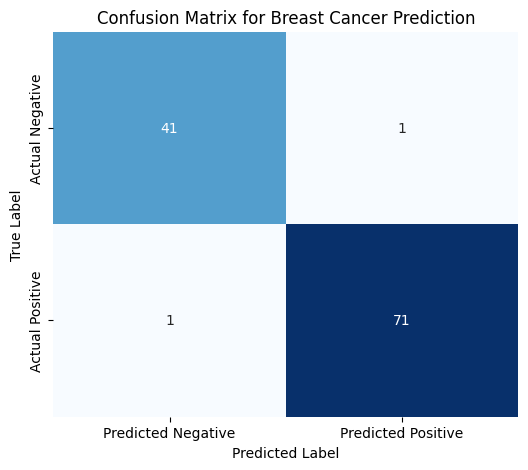


Metrics computed manually:
Accuracy: 0.9825
Sensitivity (Recall): 0.9861
Specificity: 0.9762
Precision: 0.9861
F1-Score: 0.9861

Metrics confirmed with sklearn.metrics:
Accuracy: 0.9825
Recall (Sensitivity): 0.9861
Precision: 0.9861
F1-Score: 0.9861


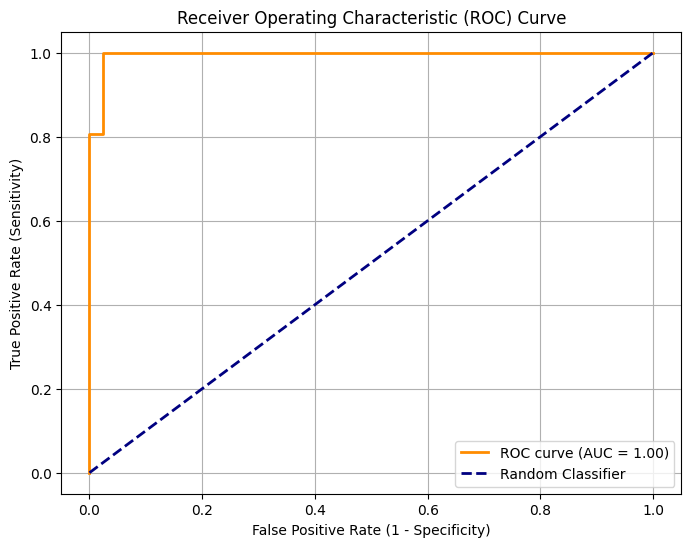

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import pandas as pd

# --- Re-load and prepare Breast Cancer data (same as Module 4 for consistency) --- #
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

scaler_bc = StandardScaler()
X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled = scaler_bc.transform(X_bc_test)

# Use Logistic Regression (one of the high-performing models from Module 4) to get predictions
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_bc_train_scaled, y_bc_train)
y_pred_lr = lr_model.predict(X_bc_test_scaled)
y_proba_lr = lr_model.predict_proba(X_bc_test_scaled)[:, 1] # Probability of the positive class

print("Predictions generated using Logistic Regression from Module 4.")

# 1. Build Confusion Matrix
cm = confusion_matrix(y_bc_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm)

# Optional: Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Breast Cancer Prediction')
plt.show()

# 2. Compute metrics by hand from the matrix
TN, FP, FN, TP = cm.ravel()

accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
sensitivity_manual = TP / (TP + FN)
specificity_manual = TN / (TN + FP)
precision_manual = TP / (TP + FP)
f1_manual = 2 * (precision_manual * sensitivity_manual) / (precision_manual + sensitivity_manual)

print("\nMetrics computed manually:")
print(f"Accuracy: {accuracy_manual:.4f}")
print(f"Sensitivity (Recall): {sensitivity_manual:.4f}")
print(f"Specificity: {specificity_manual:.4f}")
print(f"Precision: {precision_manual:.4f}")
print(f"F1-Score: {f1_manual:.4f}")

# 3. Confirm with sklearn.metrics
print("\nMetrics confirmed with sklearn.metrics:")
print(f"Accuracy: {accuracy_score(y_bc_test, y_pred_lr):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_bc_test, y_pred_lr):.4f}")
# Specificity is not directly available, but can be derived or calculated from TN, FP
print(f"Precision: {precision_score(y_bc_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_bc_test, y_pred_lr):.4f}")

# 4. Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_bc_test, y_proba_lr)
roc_auc = roc_auc_score(y_bc_test, y_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

✅ **Checkpoint: Optimizing for Cancer Screening**

If you had to choose one metric to optimize for a cancer screening test, which one would it be and why? What's the inherent trade-off you would face in doing so?

*Your Answer Here:*

## Review & Practice: Module 5 — Evaluation Metrics

### Summary of Module 5 Code

Module 5 moved beyond simple accuracy to introduce a suite of more nuanced **evaluation metrics** crucial for understanding classifier performance, especially in biological contexts where error costs can differ significantly. We focused on the **Breast Cancer dataset** and predictions from a `Logistic Regression` model.

Key steps and concepts covered included:

1.  **Re-loading and Preparing Data**: Ensuring consistency, we re-loaded the Breast Cancer dataset and applied the same `train_test_split` and `StandardScaler` transformations as in previous modules.
    ```python
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    bc = load_breast_cancer()
    X_bc, y_bc = bc.data, bc.target
    X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
    scaler_bc = StandardScaler()
    X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
    X_bc_test_scaled = scaler_bc.transform(X_bc_test)
    ```

2.  **Generating Predictions**: We trained a `LogisticRegression` model and obtained both hard predictions (`y_pred_lr`) and probability estimates for the positive class (`y_proba_lr`).
    ```python
    from sklearn.linear_model import LogisticRegression

    lr_model = LogisticRegression(random_state=42)
    lr_model.fit(X_bc_train_scaled, y_bc_train)
    y_pred_lr = lr_model.predict(X_bc_test_scaled)
    y_proba_lr = lr_model.predict_proba(X_bc_test_scaled)[:, 1]
    ```

3.  **Confusion Matrix**: The foundational tool for deeper metric analysis. We generated and optionally visualized the confusion matrix, which breaks down predictions into True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).
    ```python
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_bc_test, y_pred_lr)
    print(cm)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.show()
    ```

4.  **Derived Metrics**: We then calculated various metrics – `Accuracy`, `Sensitivity (Recall)`, `Specificity`, `Precision`, and `F1-Score` – both manually from the confusion matrix components and by using `sklearn.metrics` functions for confirmation.
    ```python
    from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

    TN, FP, FN, TP = cm.ravel()
    accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
    # ... (other manual calculations)

    print(f"Accuracy: {accuracy_score(y_bc_test, y_pred_lr):.4f}")
    # ... (other sklearn metrics)
    ```

5.  **ROC Curve and AUC**: Finally, we generated the **Receiver Operating Characteristic (ROC) curve** by plotting the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity) across different probability thresholds. The **Area Under the Curve (AUC)** provided a single aggregate measure of classifier performance, particularly robust to class imbalance.
    ```python
    from sklearn.metrics import roc_curve, roc_auc_score

    fpr, tpr, thresholds = roc_curve(y_bc_test, y_proba_lr)
    roc_auc = roc_auc_score(y_bc_test, y_proba_lr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.show()
    ```

Module 5 underscored that a single metric is rarely sufficient for a complete picture of model performance, especially in critical biological applications where balancing different types of errors is paramount.

### Practice Test: Module 5

**Task**: Let's consider a scenario where the cost of a False Negative (missing a disease) is extremely high, much higher than the cost of a False Positive (incorrectly flagging a healthy individual). Your goal is to adjust the `Logistic Regression` model's classification threshold to prioritize **recall (sensitivity)** on the test set (`y_bc_test`, `y_proba_lr`).

1.  From the `roc_curve` output (`fpr, tpr, thresholds`), find the threshold that yields the highest possible `recall` (TPR) while keeping the `FPR` (False Positive Rate) below a certain acceptable level, say, `0.1` (10%).
2.  Apply this new threshold to the predicted probabilities (`y_proba_lr`) to get new binary predictions (`y_pred_tuned`).
3.  Calculate and print the `recall_score` and `precision_score` using these new predictions.
4.  **Interpret**: How did adjusting the threshold impact recall and precision? Why is this trade-off important in the given scenario?

In [ ]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

# Assume y_bc_test and y_proba_lr are defined from previous cells
# Assume fpr, tpr, thresholds are defined from previous cells (roc_curve output)

# 1. Find the threshold that yields high recall while keeping FPR below 0.1
#    Iterate through thresholds and find the first one that meets the FPR criteria

# We want high TPR (recall) and FPR < 0.1
# Find the indices where FPR is less than or equal to 0.1
acceptable_fpr_indices = np.where(fpr <= 0.1)[0]

# If there are any acceptable FPRs, choose the one with the highest TPR (recall)
if len(acceptable_fpr_indices) > 0:
    # Find the index corresponding to the highest TPR within the acceptable FPR range
    best_threshold_index = acceptable_fpr_indices[np.argmax(tpr[acceptable_fpr_indices])]
    tuned_threshold = thresholds[best_threshold_index]

    print(f"Selected Threshold: {tuned_threshold:.4f}")
    print(f"Recall at this threshold (TPR): {tpr[best_threshold_index]:.4f}")
    print(f"FPR at this threshold: {fpr[best_threshold_index]:.4f}")
else:
    tuned_threshold = 0.5 # Default if no threshold meets criteria
    print("No threshold found that keeps FPR below 0.1. Using default 0.5.")

# 2. Apply this new threshold to get new binary predictions
y_pred_tuned = (y_proba_lr >= tuned_threshold).astype(int)

# 3. Calculate and print the recall_score and precision_score
recall_tuned = recall_score(y_bc_test, y_pred_tuned)
precision_tuned = precision_score(y_bc_test, y_pred_tuned)

print(f"\nRecall (Sensitivity) with tuned threshold: {recall_tuned:.4f}")
print(f"Precision with tuned threshold: {precision_tuned:.4f}")

# 4. Your Interpretation:
# --- Type your interpretation here ---

---

---